In [7]:
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {device}")

Running on: cuda


Bài A1 (Loại A) – Perceptron thủ công
Yêu cầu. Viết code Python/PyTorch thực hiện các bước sau:
1. Tạo một perceptron bằng nn.Linear(3, 1) với 3 đầu vào và 1 đầu ra.
2. Gán thủ công trọng số w = [0.5, −0.3, 0.8] và bias b = 0.2 bằng torch.no_grad().
3. Tạo tensor đầu vào x = [1.0, 2.0, −1.0].
4. Tính đầu ra trước kích hoạt (weighted sum + bias) và sau khi áp dụng hàm Sigmoid.
5. In ra: trọng số, bias, giá trị z (trước kích hoạt), và giá trị yˆ (sau Sigmoid).
Kết quả mong đợi: z = 0.5 × 1.0 + (−0.3) × 2.0 + 0.8 × (−1.0) + 0.2 = −0.7, yˆ = σ(−0.7) ≈
0.3318.

In [11]:
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {device}")

perceptron = nn.Linear(3, 1).to(device)

with torch.no_grad():
    perceptron.weight.copy_(torch.tensor([[0.5, -0.3, 0.8]]))
    perceptron.bias.copy_(torch.tensor([0.2]))

x = torch.tensor([1.0, 2.0, -1.0]).to(device)


z = perceptron(x) 
y_hat = torch.sigmoid(z)


print(f"Bài A1 (Chạy trên {device}) ---")
print(f"Trọng số (w): {perceptron.weight.detach().cpu().numpy()}")
print(f"Bias (b): {perceptron.bias.detach().cpu().numpy()}")
print(f"Giá trị z (trước kích hoạt): {z.item():.1f}")
print(f"Giá trị y_hat (sau Sigmoid): {y_hat.item():.4f}")

Running on: cuda
Bài A1 (Chạy trên cuda) ---
Trọng số (w): [[ 0.5 -0.3  0.8]]
Bias (b): [0.2]
Giá trị z (trước kích hoạt): -0.7
Giá trị y_hat (sau Sigmoid): 0.3318


- Lỗi cú pháp (Syntax Errors):
    - Thiếu dấu chấm (.): Dòng torch manual_seed(42) thiếu dấu chấm sau torch. Đúng phải là torch.manual_seed(42).
    Thiếu dấu gán (=): Dòng sample_input torch.tensor(...) thiếu dấu bằng. Đúng phải là sample_input = torch.tensor(...).
    - Sai định dạng F-string: Trong các câu lệnh print, code mẫu sử dụng dấu ngoặc đơn (...) bên trong chuỗi f-string thay vì dấu ngoặc nhọn {...}.
    - Ví dụ: (sample_input.numpy()) phải sửa thành {sample_input.numpy()}.
- Lỗi sai yêu cầu đề bài:
    - Sai hàm kích hoạt: Đề bài yêu cầu sử dụng Sigmoid, nhưng code mẫu lại sử dụng torch.relu().
    - Sai giá trị đầu vào: Đề bài yêu cầu $x = [0.5, -1.0]$, nhưng code mẫu đang để [0.5, 1.0].


In [12]:
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)

perceptron = nn.Linear(2, 1).to(device)

sample_input = torch.tensor([0.5, -1.0]).to(device)

weighted_sum = perceptron(sample_input)

output = torch.sigmoid(weighted_sum)

print(f"Bài B1 (Sửa lỗi)")
print(f"Dau vao: {sample_input.cpu().numpy()}")
print(f"Trong so: {perceptron.weight.detach().cpu().numpy()}")
print(f"Bias: {perceptron.bias.detach().cpu().numpy()}")
print(f"z (truoc kich hoat): {weighted_sum.item():.4f}")
print(f"Dau ra sau kich hoat (Sigmoid): {output.item():.4f}")



Bài B1 (Sửa lỗi)
Dau vao: [ 0.5 -1. ]
Trong so: [[0.5406104 0.5869042]]
Bias: [-0.16565566]
z (truoc kich hoat): -0.4823
Dau ra sau kich hoat (Sigmoid): 0.3817


Sigmoid    | Khoảng giá trị: [0.0025, 0.9975]
Tanh       | Khoảng giá trị: [-1.0000, 1.0000]
ReLU       | Khoảng giá trị: [0.0000, 6.0000]
LeakyReLU  | Khoảng giá trị: [-0.6000, 6.0000]


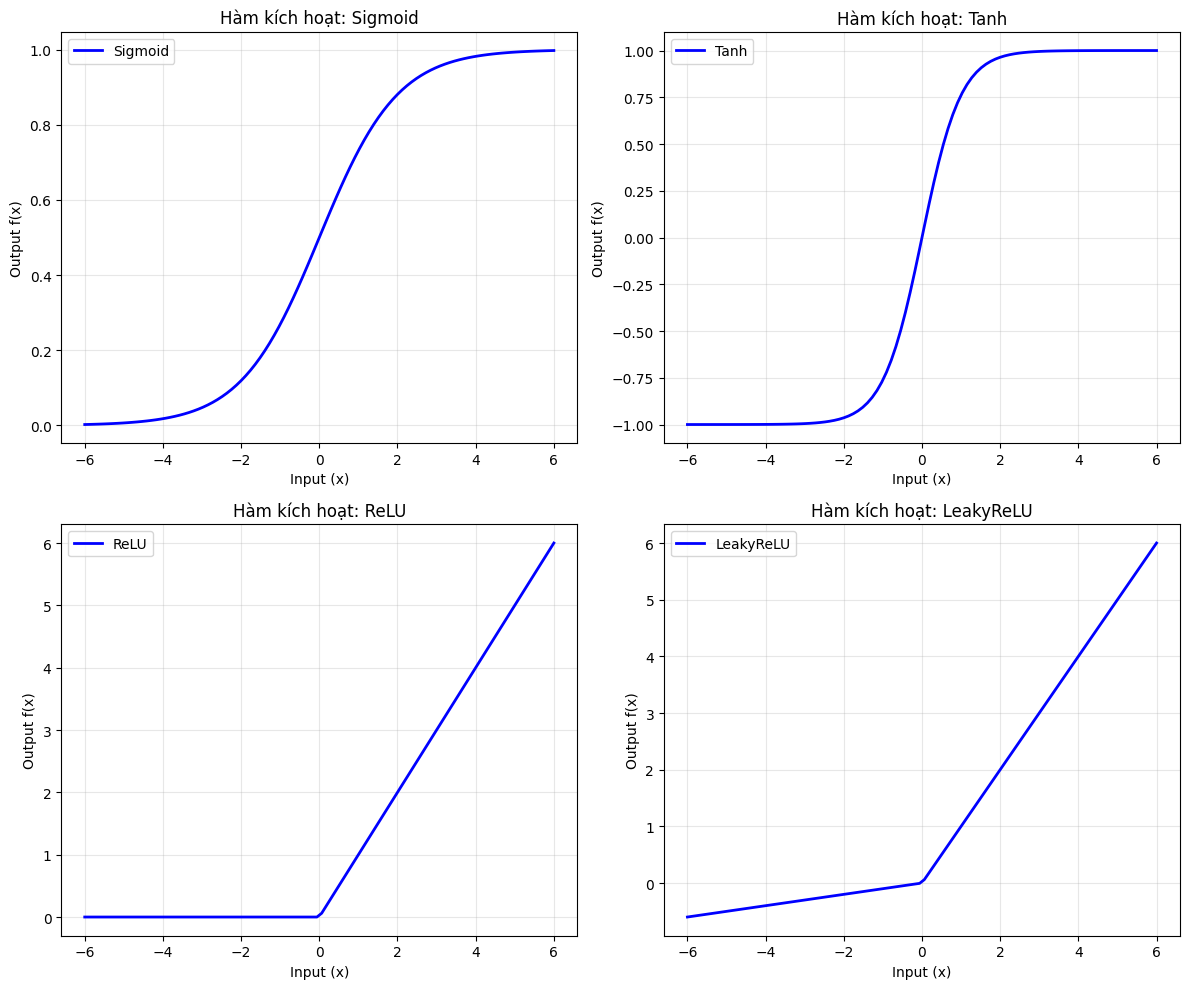

In [13]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

x_vals = torch.linspace(-6, 6, 100)

activations = {
    "Sigmoid": nn.Sigmoid(), 
    "Tanh": nn.Tanh(),
    "ReLU": nn.ReLU(), 
    "LeakyReLU": nn.LeakyReLU(negative_slope=0.1)
}

plt.figure(figsize=(12,10))
results = {}

for i, (name, func) in enumerate(activations.items()):
    y_vals = func(x_vals)
    results[name] = y_vals
    
    plt.subplot(2, 2, i + 1)
    plt.plot(x_vals.numpy(), y_vals.detach().numpy(), label=name, color='blue', linewidth=2)
    plt.title(f"Hàm kích hoạt: {name}")
    plt.xlabel("Input (x)")
    plt.ylabel("Output f(x)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    val_min = y_vals.min().item()
    val_max = y_vals.max().item()
    print(f"{name:10} | Khoảng giá trị: [{val_min:.4f}, {val_max:.4f}]")

plt.tight_layout()
plt.show()

In [15]:
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


logits = torch.tensor([[1.0, -0.5, 2.0], 
                       [0.1, 0.5, 0.2]]).to(device)

softmax_fn = nn.Softmax(dim=1)
probs = softmax_fn(logits)


sum_probs = torch.sum(probs, dim=1)

print("Bài A3")
print(f"Logits:\n{logits.cpu().numpy()}")
print(f"\nOutput Softmax (Xác suất):\n{probs.cpu().detach().numpy()}")
print(f"\nTổng xác suất từng mẫu: {sum_probs.cpu().detach().numpy()}")


Bài A3
Logits:
[[ 1.  -0.5  2. ]
 [ 0.1  0.5  0.2]]

Output Softmax (Xác suất):
[[0.2537162  0.05661173 0.68967205]
 [0.27800977 0.41474187 0.30724832]]

Tổng xác suất từng mẫu: [0.99999994 1.        ]


GIẢI THÍCH:
- Trong PyTorch, tensor dữ liệu thường có dạng (Batch_size, Features).
- Ở đây, dim=0 là chiều của Batch (mẫu), dim=1 là chiều của Features (các lớp).
- Ta cần tính xác suất cho TỪNG MẪU đơn lẻ, nghĩa là tổng các giá trị 
  theo hàng ngang (chiều các lớp) phải bằng 1. 
- Nếu dùng dim=0, Softmax sẽ tính tổng theo cột, dẫn đến việc xác suất 
  của một lớp bị phụ thuộc vào các mẫu khác trong batch, điều này sai logic phân loại.


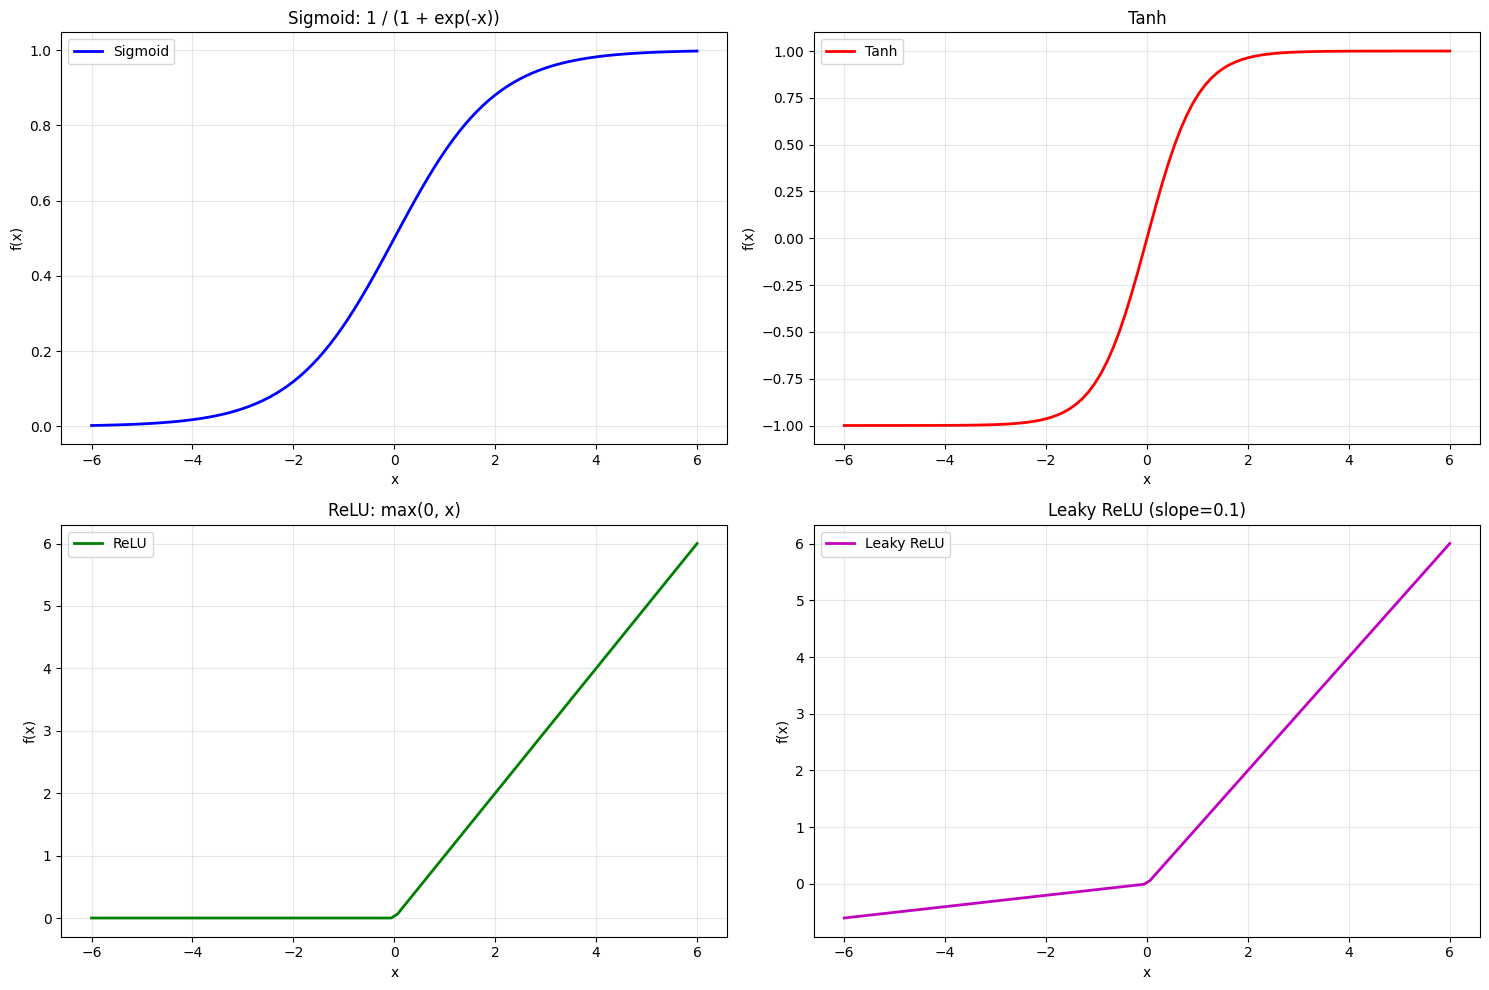

In [16]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

x_vals = torch.linspace(-6, 6, 100).to(device)

sigmoid_fn = nn.Sigmoid()
tanh_fn = nn.Tanh()
relu_fn = nn.ReLU()
leaky_relu_fn = nn.LeakyReLU(negative_slope=0.1)

with torch.no_grad():
    y_sigmoid = sigmoid_fn(x_vals)
    y_tanh = tanh_fn(x_vals)
    y_relu = relu_fn(x_vals)
    y_leaky_relu = leaky_relu_fn(x_vals)

x_np = x_vals.cpu().numpy()

plt.figure(figsize=(15, 10))

# Subplot 1: Sigmoid
plt.subplot(2, 2, 1)
plt.plot(x_np, y_sigmoid.cpu().numpy(), 'b-', linewidth=2, label='Sigmoid')
plt.title('Sigmoid: 1 / (1 + exp(-x))')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, alpha=0.3)
plt.legend()

# Subplot 2: Tanh
plt.subplot(2, 2, 2)
plt.plot(x_np, y_tanh.cpu().numpy(), 'r-', linewidth=2, label='Tanh')
plt.title('Tanh')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, alpha=0.3)
plt.legend()

# Subplot 3: ReLU
plt.subplot(2, 2, 3)
plt.plot(x_np, y_relu.cpu().numpy(), 'g-', linewidth=2, label='ReLU')
plt.title('ReLU: max(0, x)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, alpha=0.3)
plt.legend()

# Subplot 4: Leaky ReLU
plt.subplot(2, 2, 4)
plt.plot(x_np, y_leaky_relu.cpu().numpy(), 'm-', linewidth=2, label='Leaky ReLU')
plt.title('Leaky ReLU (slope=0.1)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

- Lỗi sai tiêu đề:

Subplot 1: Vẽ dữ liệu của Sigmoid nhưng tiêu đề lại ghi là ReLU: max(0, x).

Subplot 3: Vẽ dữ liệu của ReLU nhưng tiêu đề lại ghi là Sigmoid: 1 / (1 + exp(-x)).

- Lỗi không nhất quán tham số:

Ở phần khởi tạo, leaky_relu_fn dùng negative_slope=0.01, nhưng tiêu đề ở Subplot 4 lại ghi là slope=0.1. Cần thống nhất về một giá trị (thường là 0.1 để đồ thị dễ quan sát hơn).

In [1]:
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(100, 64)  # Lớp 1: Input(100) -> Hidden(64)
        self.fc2 = nn.Linear(64, 32)   # Lớp 2: Hidden(64) -> Hidden(32)
        self.fc3 = nn.Linear(32, 5)    # Lớp 3: Hidden(32) -> Output(5)
        
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)  
        return x

model = SimpleMLP().to(device)
print("--- Kiến trúc Model ---")
print(model)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTổng số tham số có thể huấn luyện: {total_params:,}")

dummy_batch = torch.randn(4, 100).to(device)

with torch.no_grad():
    output = model(dummy_batch)

print(f"\nShape của input batch: {dummy_batch.shape}")
print(f"Shape của output batch: {output.shape}")

--- Kiến trúc Model ---
SimpleMLP(
  (fc1): Linear(in_features=100, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=5, bias=True)
  (relu): ReLU()
)

Tổng số tham số có thể huấn luyện: 8,709

Shape của input batch: torch.Size([4, 100])
Shape của output batch: torch.Size([4, 5])


Lớp,nin​,nout​,Phép tính,Số tham số
fc1,100,64,100×64+64,"6,464"
fc2,64,32,64×32+32,"2,080"
fc3,32,5,32×5+5,165
Tổng,,,,"8,709"

In [5]:
print("--- Kiểm chứng số lượng tham số ---")
total_params_check = 0
for name, param in model.named_parameters():
    if param.requires_grad:
        num_p = param.numel()
        total_params_check += num_p
        print(f"Lớp {name:15} | Shape: {str(list(param.shape)):20} | Tham số: {num_p}")

print(f"\n=> Tổng tham số kiểm chứng: {total_params_check:,}")

batch_sizes = [1, 4, 16, 32]
print("\n--- Kiểm tra Shape đầu ra ---")

for bs in batch_sizes:
    x = torch.randn(bs, 100).to(device)
    
    with torch.no_grad():
        out = model(x)
    
    print(f"Batch Size: {bs:2} | Output Shape: {list(out.shape)}")

--- Kiểm chứng số lượng tham số ---
Lớp fc1.weight      | Shape: [64, 100]            | Tham số: 6400
Lớp fc1.bias        | Shape: [64]                 | Tham số: 64
Lớp fc2.weight      | Shape: [32, 64]             | Tham số: 2048
Lớp fc2.bias        | Shape: [32]                 | Tham số: 32
Lớp fc3.weight      | Shape: [5, 32]              | Tham số: 160
Lớp fc3.bias        | Shape: [5]                  | Tham số: 5

=> Tổng tham số kiểm chứng: 8,709

--- Kiểm tra Shape đầu ra ---
Batch Size:  1 | Output Shape: [1, 5]
Batch Size:  4 | Output Shape: [4, 5]
Batch Size: 16 | Output Shape: [16, 5]
Batch Size: 32 | Output Shape: [32, 5]


- Thiếu super().__init__(): nếu không gọi hàm khởi tạo của lớp cha (nn.Module), mô hình sẽ không thể đăng ký và quản lý các tham số (weights, bias). Hậu quả là model.parameters() sẽ trả về rỗng và không thể huấn luyện.Sai kích thước lớp ẩn fc2: Đề bài yêu cầu kiến trúc $100 \to 64 \to 32 \to 5$. Tuy nhiên, code mẫu khai báo nn.Linear(hidden_size, hidden_size) (tương đương $64 \to 64$), không khớp với yêu cầu lớp ẩn thứ hai phải là 32.
- Lỗi Size Mismatch tại lớp fc3: Lớp fc3 được khai báo đầu vào là hidden_size // 2 (tức là 32), nhưng lớp fc2 liền trước đó lại trả ra kết quả có kích thước 64. Điều này sẽ gây lỗi văng chương trình (RuntimeError) ngay khi thực hiện forward pass.
- Lỗi cú pháp F-string: Ở dòng in kết quả cuối cùng, biến predictions.shape không được đặt trong dấu ngoặc nhọn {}. Do đó, Python sẽ in ra nguyên văn chuỗi ký tự thay vì giá trị thực tế của shape.

In [6]:
import torch
import torch.nn as nn

class SimpleMLP(nn.Module):
    def __init__(self, input_size, hidden_1, hidden_2, num_classes):
        super(SimpleMLP, self).__init__()
        
        self.fc1 = nn.Linear(input_size, hidden_1)
        self.relu1 = nn.ReLU()
        
        self.fc2 = nn.Linear(hidden_1, hidden_2)
        self.relu2 = nn.ReLU()
        
        self.fc3 = nn.Linear(hidden_2, num_classes)
        
    def forward(self, x):
        # Forward pass mạch lạc
        out = self.relu1(self.fc1(x))
        out = self.relu2(self.fc2(out))
        out = self.fc3(out)
        return out

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = SimpleMLP(input_size=100, hidden_1=64, hidden_2=32, num_classes=5).to(device)

print("Kien truc MLP chuẩn:")
print(model)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTong so tham so: {total_params:,}")

batch_size = 4
dummy_input = torch.randn(batch_size, 100).to(device)

with torch.no_grad():
    predictions = model(dummy_input)

print(f"Shape dau ra: {predictions.shape}")

Kien truc MLP chuẩn:
SimpleMLP(
  (fc1): Linear(in_features=100, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=32, out_features=5, bias=True)
)

Tong so tham so: 8,709
Shape dau ra: torch.Size([4, 5])


In [7]:
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

mse_fn = nn.MSELoss()
preds_reg = torch.tensor([1.0, 2.5, 3.8]).to(device)
targets_reg = torch.tensor([1.2, 2.3, 4.0]).to(device)
loss_mse = mse_fn(preds_reg, targets_reg)

ce_fn = nn.CrossEntropyLoss()
logits_mc = torch.tensor([[2.0, 0.5, -1.0], [0.1, 1.5, 0.2]]).to(device)
targets_mc = torch.tensor([0, 1]).long().to(device) # Nhãn là chỉ số lớp (0 và 1)
loss_ce = ce_fn(logits_mc, targets_mc)

bce_fn = nn.BCEWithLogitsLoss()
logits_bc = torch.tensor([-0.5, 1.5, -2.0, 3.0]).to(device)
targets_bc = torch.tensor([0.0, 1.0, 0.0, 1.0]).to(device)
loss_bce = bce_fn(logits_bc.view(-1, 1), targets_bc.view(-1, 1))

print(f"--- Bài A6: Minh họa Loss Functions ---")
print(f"1. MSE Loss: {loss_mse.item():.4f}")
print(f"   Input: {preds_reg.cpu().numpy()} | Target: {targets_reg.cpu().numpy()}")

print(f"\n2. Cross-Entropy Loss: {loss_ce.item():.4f}")
print(f"   Logits:\n{logits_mc.cpu().numpy()}\n   Target Indices: {targets_mc.cpu().numpy()}")

print(f"\n3. BCEWithLogitsLoss: {loss_bce.item():.4f}")
print(f"   Logits: {logits_bc.cpu().numpy()} | Target: {targets_bc.cpu().numpy()}")

--- Bài A6: Minh họa Loss Functions ---
1. MSE Loss: 0.0400
   Input: [1.  2.5 3.8] | Target: [1.2 2.3 4. ]

2. Cross-Entropy Loss: 0.3297
   Logits:
[[ 2.   0.5 -1. ]
 [ 0.1  1.5  0.2]]
   Target Indices: [0 1]

3. BCEWithLogitsLoss: 0.2128
   Logits: [-0.5  1.5 -2.   3. ] | Target: [0. 1. 0. 1.]


Lỗi 1 (F-string Syntax): Ở các dòng print, biến không được đặt trong dấu ngoặc nhọn {}. Ví dụ: (predictions_reg.numpy()) sẽ in ra nguyên văn chuỗi đó thay vì giá trị.

Lỗi 2 (Cross-Entropy Target Type): Trong PyTorch, nn.CrossEntropyLoss mặc định yêu cầu nhãn (target) là các chỉ số lớp (class indices) kiểu số nguyên (LongTensor), không phải dạng One-hot vector kiểu float như trong code mẫu.

Lỗi 3 (Device/Numpy Error): Nếu chạy trên Kaggle GPU, việc gọi .numpy() trực tiếp trên tensor đang ở GPU sẽ gây lỗi. Cần .detach().cpu().numpy().

Lỗi 4 (Logic nhãn): Yêu cầu đề bài bảo dùng nhãn là chỉ số lớp [0, 1], nhưng code mẫu lại định nghĩa targets_mc là ma trận One-hot.

In [8]:
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- MSE Loss ---
loss_mse_fn = nn.MSELoss()
predictions_reg = torch.tensor([1.0, 2.5, 3.8]).to(device)
targets_reg = torch.tensor([1.2, 2.3, 4.0]).to(device)
mse = loss_mse_fn(predictions_reg, targets_reg)

print("MSE Loss (Regression):")
print(f" Predictions: {predictions_reg.cpu().numpy()}")
print(f" Targets: {targets_reg.cpu().numpy()}")
print(f" MSE Loss: {mse.item():.4f}")

# --- Cross-Entropy Loss ---
loss_ce_fn = nn.CrossEntropyLoss()
predictions_mc = torch.tensor([[2.0, 0.5, -1.0], 
                                [0.1, 1.5, 0.2]]).to(device)

# SỬA LỖI: Dùng chỉ số lớp [0, 1] và ép kiểu về Long
targets_mc = torch.tensor([0, 1]).long().to(device) 

ce = loss_ce_fn(predictions_mc, targets_mc)

print("\nCross-Entropy Loss (Multi-class):")
print(f" Logits:\n {predictions_mc.cpu().numpy()}")
print(f" Targets: {targets_mc.cpu().numpy()}")
print(f" CE Loss: {ce.item():.4f}")

MSE Loss (Regression):
 Predictions: [1.  2.5 3.8]
 Targets: [1.2 2.3 4. ]
 MSE Loss: 0.0400

Cross-Entropy Loss (Multi-class):
 Logits:
 [[ 2.   0.5 -1. ]
 [ 0.1  1.5  0.2]]
 Targets: [0 1]
 CE Loss: 0.3297


- Lỗi 1: Dùng sai hàm Loss (nn.BCELoss vs nn.BCEWithLogitsLoss): nn.BCELoss yêu cầu đầu vào phải là xác suất (nằm trong khoảng $[0, 1]$, thường là sau khi qua hàm Sigmoid). Trong khi đó, dữ liệu đầu vào là logits (có giá trị âm như $-0.5, -2.0$). Nếu đưa số âm vào BCELoss, hàm $\log(x)$ bên trong sẽ bị lỗi (vì $\log$ của số âm không xác định), dẫn đến kết quả NaN.
- Lỗi 2: Thiếu bước Reshape: Đề bài yêu cầu tensor phải có shape $(4, 1)$, nhưng code mẫu để mặc định là $(4,)$. Trong các mạng nơ-ron thực tế, việc đưa về shape $(N, 1)$ giúp đồng nhất với đầu ra của lớp nn.Linear(hidden, 1).
- Lỗi 3: Lỗi thiết bị (Kaggle GPU): Tương tự các bài trước, gọi .numpy() trên tensor ở GPU mà không có .cpu() sẽ văng lỗi ngay lập tức.
- Lỗi 4: Sai cú pháp F-string: (Nếu copy nguyên văn từ đề) Một số chỗ dùng ngoặc đơn () thay vì ngoặc nhọn {} bên trong f-string.

In [9]:
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

loss_bce_fn = nn.BCEWithLogitsLoss()

predictions_bc = torch.tensor([-0.5, 1.5, -2.0, 3.0]).to(device)
targets_bc = torch.tensor([0.0, 1.0, 0.0, 1.0]).to(device)


predictions_bc = predictions_bc.view(4, 1)
targets_bc = targets_bc.view(4, 1)

bce_loss = loss_bce_fn(predictions_bc, targets_bc)

print("--- Kết quả Bài B5 (Sửa lỗi) ---")
print(f"Logits Reshaped:\n{predictions_bc.cpu().numpy()}")
print(f"Targets Reshaped:\n{targets_bc.cpu().numpy()}")
print(f"BCEWithLogitsLoss: {bce_loss.item():.4f}")



--- Kết quả Bài B5 (Sửa lỗi) ---
Logits Reshaped:
[[-0.5]
 [ 1.5]
 [-2. ]
 [ 3. ]]
Targets Reshaped:
[[0.]
 [1.]
 [0.]
 [1.]]
BCEWithLogitsLoss: 0.2128


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim

model = nn.Linear(10, 2).to(device)

initial_w = model.weight[0, 0].item()
print(f"--- Bài A7 ---")
print(f"Giá trị ban đầu weight[0, 0]: {initial_w:.4f}")

optimizer_sgd = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
optimizer_adam = optim.Adam(model.parameters(), lr=0.001)

dummy_input = torch.randn(5, 10).to(device)
dummy_target = torch.randn(5, 2).to(device)
criterion = nn.MSELoss()


optimizer_sgd.zero_grad()              
outputs = model(dummy_input)            
loss = criterion(outputs, dummy_target) 
loss.backward()                         
optimizer_sgd.step()                    


final_w = model.weight[0, 0].item()
print(f"Giá trị sau 1 bước SGD weight[0, 0]: {final_w:.4f}")
print(f"Loss: {loss.item():.4f}")
print(f"Độ thay đổi (delta): {abs(final_w - initial_w):.6f}")

--- Bài A7 ---
Giá trị ban đầu weight[0, 0]: -0.0294
Giá trị sau 1 bước SGD weight[0, 0]: -0.0252
Loss: 0.6205
Độ thay đổi (delta): 0.004189


Lỗi: Vị trí của zero_grad()

Mô tả: Trong code mẫu, optimizer_sgd.zero_grad() được gọi sau loss.backward() và trước optimizer_sgd.step().

Hậu quả: Lệnh backward() có nhiệm vụ tính toán các gradient và lưu vào thuộc tính .grad của các tham số. Nếu bạn gọi zero_grad() ngay sau đó, toàn bộ gradient vừa tính được sẽ bị xóa sạch (về 0). Khi gọi step(), Optimizer sẽ không thấy gradient đâu để cập nhật, dẫn đến trọng số đứng yên.

Hậu quả khi huấn luyện nhiều epoch: Mô hình sẽ không học được gì (Loss không giảm hoặc giảm cực chậm do ngẫu nhiên), gây lãng phí tài nguyên GPU và thời gian.

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)

dummy_model = nn.Linear(10, 2).to(device)
print(f"Gia tri ban dau weight[0,0]: {dummy_model.weight[0,0].item():.4f}")

optimizer_sgd = optim.SGD(dummy_model.parameters(), lr=0.01, momentum=0.9)
criterion = nn.MSELoss()

dummy_input = torch.randn(5, 10).to(device)
dummy_target = torch.randn(5, 2).to(device)


optimizer_sgd.zero_grad()

outputs = dummy_model(dummy_input)

loss = criterion(outputs, dummy_target)

loss.backward()

optimizer_sgd.step()

print(f"Gia tri sau buoc SGD chuẩn: {dummy_model.weight[0,0].item():.4f}")
print(f"Loss: {loss.item():.4f}")

Gia tri ban dau weight[0,0]: 0.2418
Gia tri sau buoc SGD chuẩn: 0.2417
Loss: 0.9035


In [13]:
import torch
from torch.utils.data import DataLoader, TensorDataset

X_xor = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]], dtype=torch.float32)
y_xor = torch.tensor([[0.], [1.], [1.], [0.]], dtype=torch.float32)

dataset = TensorDataset(X_xor, y_xor)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

print(f"Total samples: {len(dataset)}")
print(f"Batch size: {dataloader.batch_size}")

for inputs, labels in dataloader:
    print(f"Input shape: {inputs.shape}")
    print(f"Label shape: {labels.shape}")
    break

Total samples: 4
Batch size: 4
Input shape: torch.Size([4, 2])
Label shape: torch.Size([4, 1])


In [14]:
import torch
import torch.nn as nn

class XORNet(nn.Module):
    def __init__(self):
        super(XORNet, self).__init__()
        self.fc1 = nn.Linear(2, 8)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(8, 1)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = XORNet().to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

test_input = torch.tensor([[0., 0.], [1., 1.]]).to(device)
with torch.no_grad():
    test_output = model(test_input)
print(f"Test output logits:\n{test_output.cpu().numpy()}")

XORNet(
  (fc1): Linear(in_features=2, out_features=8, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=8, out_features=1, bias=True)
)
Total parameters: 33
Test output logits:
[[-0.33250216]
 [-0.09565834]]


Epoch [200/1000], Loss: 0.0043
Epoch [400/1000], Loss: 0.0014
Epoch [600/1000], Loss: 0.0007
Epoch [800/1000], Loss: 0.0004
Epoch [1000/1000], Loss: 0.0003


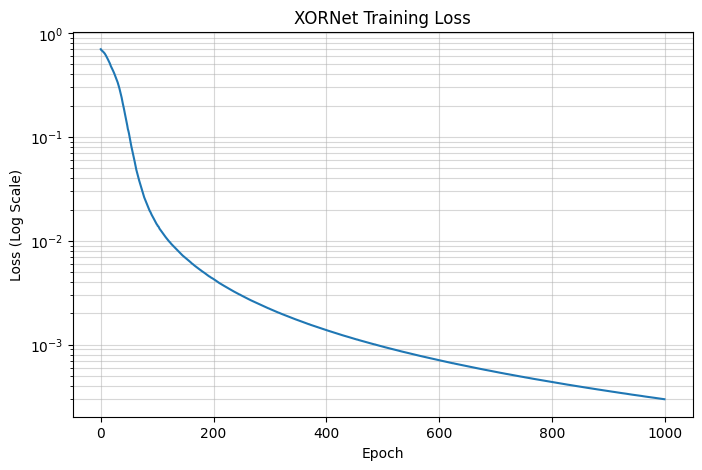

In [15]:
import torch.optim as optim
import matplotlib.pyplot as plt

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.05)
num_epochs = 1000
loss_history = []

for epoch in range(num_epochs):
    epoch_loss = 0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(dataloader)
    loss_history.append(avg_loss)
    
    if (epoch + 1) % 200 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss (Log Scale)')
plt.title('XORNet Training Loss')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

In [16]:
model.eval()
with torch.no_grad():
    X_xor = X_xor.to(device)
    y_xor = y_xor.to(device)
    
    logits = model(X_xor)
    probs = torch.sigmoid(logits)
    preds = (probs >= 0.5).float()
    
    accuracy = (preds == y_xor).float().mean()
    print(f"Accuracy: {accuracy.item()*100:.2f}%\n")
    
    print(f"{'Input':<12} | {'True':<6} | {'Prob':<8} | {'Pred':<6} | {'Status'}")
    print("-" * 55)
    
    inputs_np = X_xor.cpu().numpy()
    labels_np = y_xor.cpu().numpy()
    probs_np = probs.cpu().numpy()
    preds_np = preds.cpu().numpy()
    
    for i in range(len(inputs_np)):
        status = "Dung" if preds_np[i] == labels_np[i] else "Sai"
        print(f"{str(inputs_np[i]):<12} | {labels_np[i][0]:<6.0f} | {probs_np[i][0]:<8.4f} | {preds_np[i][0]:<6.0f} | {status}")

model.train()

Accuracy: 100.00%

Input        | True   | Prob     | Pred   | Status
-------------------------------------------------------
[0. 0.]      | 0      | 0.0001   | 0      | Dung
[0. 1.]      | 1      | 0.9991   | 1      | Dung
[1. 0.]      | 1      | 0.9999   | 1      | Dung
[1. 1.]      | 0      | 0.0001   | 0      | Dung


XORNet(
  (fc1): Linear(in_features=2, out_features=8, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=8, out_features=1, bias=True)
)

- Lỗi 1: Sai thứ tự optimizer.zero_grad(): Trong code mẫu, lệnh này đặt sau step(). Mặc dù trong một số trường hợp đơn giản nó có vẻ chạy được, nhưng đây là một thói quen xấu và sai quy trình chuẩn.

- Lỗi 2: Thiếu quản lý thiết bị (device)

Trong PyTorch, các gradient được tích lũy (accumulated) vào thuộc tính .grad của các tham số mỗi khi hàm .backward() được gọi.

zero_grad(): Xóa bỏ các gradient cũ còn sót lại từ batch/epoch trước. Nếu không xóa, gradient mới sẽ bị cộng dồn vào gradient cũ.

backward(): Tính toán gradient của hàm mất mát dựa trên các trọng số hiện tại và lưu vào vùng nhớ đệm .grad.

step(): Cập nhật trọng số dựa trên các giá trị đang có trong .grad.

Hậu quả nếu sai thứ tự: Nếu bạn không xóa gradient trước khi backward, Optimizer sẽ cập nhật trọng số bằng tổng gradient của nhiều batch/epoch khác nhau, khiến hướng cập nhật bị sai lệch hoàn toàn so với vector gradient hiện tại.

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)

X_xor = torch.tensor([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
y_xor = torch.tensor([[0.],[1.],[1.],[0.]])
xor_dataset = TensorDataset(X_xor, y_xor)
xor_dataloader = DataLoader(xor_dataset, batch_size=4, shuffle=True)

class XORNet(nn.Module):
    def __init__(self):
        super(XORNet, self).__init__()
        self.fc1 = nn.Linear(2, 8)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(8, 1)
        
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

xor_model = XORNet().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(xor_model.parameters(), lr=0.05)
num_epochs = 1000
losses_history = []

for epoch in range(num_epochs):
    for inputs, labels in xor_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = xor_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
    losses_history.append(loss.item())
    
    if (epoch + 1) % 200 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

print(f"Hoan thanh! Loss cuoi: {loss.item():.4f}")

Epoch [200/1000], Loss: 0.0011
Epoch [400/1000], Loss: 0.0002
Epoch [600/1000], Loss: 0.0001
Epoch [800/1000], Loss: 0.0001
Epoch [1000/1000], Loss: 0.0000
Hoan thanh! Loss cuoi: 0.0000


- Lỗi 1: Sai chế độ mô hình (xor_model.train()):Giải thích: Đề bài yêu cầu đánh giá, nhưng code lại để mode train().Hậu quả: Các lớp như Dropout hoặc Batch Normalization (nếu có) sẽ vẫn hoạt động như đang huấn luyện, dẫn đến kết quả dự đoán không ổn định và không chính xác.
- Lỗi 2: Thiếu torch.no_grad():Giải thích: Khi đánh giá, chúng ta không cần tính đạo hàm.Hậu quả: PyTorch sẽ vẫn âm thầm xây dựng đồ thị tính toán (computation graph), gây tốn bộ nhớ GPU/RAM vô ích và làm chậm tốc độ xử lý.
- Lỗi 3: Sai hàm chuyển đổi xác suất (torch.relu):Giải thích: Để chuyển logit về xác suất $[0, 1]$ trong bài toán nhị phân, ta phải dùng Sigmoid.Hậu quả: ReLU chỉ giữ nguyên số dương và biến số âm thành 0. Nó không giới hạn đầu ra ở mức 1.0, khiến logic so sánh test_probs >= 0.5 trở nên vô nghĩa.
- Lỗi 4: Lỗi thiết bị và chuyển đổi dữ liệu:Giải thích: Gọi .numpy() trực tiếp trên tensor GPU (Kaggle) mà không .cpu() sẽ gây lỗi. Ngoài ra, X_xor cần được đẩy lên cùng device với model.
- Lỗi 5: Thiếu bước trả về train() mode:Giải thích: Theo yêu cầu, sau khi eval xong phải chuyển lại mode huấn luyện để sẵn sàng cho các công việc tiếp theo.

In [18]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
xor_model.to(device)
X_xor = X_xor.to(device)
y_xor = y_xor.to(device)

xor_model.eval()

with torch.no_grad():
    test_logits = xor_model(X_xor)
    test_probs = torch.sigmoid(test_logits)
    predicted = (test_probs >= 0.5).float()
    accuracy = (predicted == y_xor).float().mean()

    print(f"Accuracy: {accuracy.item()*100:.2f}%")
    print("\nKet qua chi tiet:")
    print(f"{'Input':<15} | {'That':<5} | {'Prob':<8} | {'Du doan':<8} | {'Dung?'}")
    print("-" * 60)

    X_cpu = X_xor.cpu().numpy()
    y_cpu = y_xor.cpu().numpy()
    probs_cpu = test_probs.cpu().numpy()
    preds_cpu = predicted.cpu().numpy()

    for i in range(len(X_cpu)):
        inp = X_cpu[i]
        true = y_cpu[i][0]
        prob = probs_cpu[i][0]
        pred = preds_cpu[i][0]
        ok = "Dung" if pred == true else "Sai"
        print(f"{str(inp):<15} | {true:.0f} | {prob:.4f} | {pred:.0f} | {ok}")

xor_model.train()

Accuracy: 100.00%

Ket qua chi tiet:
Input           | That  | Prob     | Du doan  | Dung?
------------------------------------------------------------
[0. 0.]         | 0 | 0.0001 | 0 | Dung
[0. 1.]         | 1 | 1.0000 | 1 | Dung
[1. 0.]         | 1 | 1.0000 | 1 | Dung
[1. 1.]         | 0 | 0.0000 | 0 | Dung


XORNet(
  (fc1): Linear(in_features=2, out_features=8, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=8, out_features=1, bias=True)
)

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)

X_nand = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]], dtype=torch.float32)
y_nand = torch.tensor([[1.], [1.], [1.], [0.]], dtype=torch.float32)

dataset = TensorDataset(X_nand, y_nand)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

class NANDNet(nn.Module):
    def __init__(self):
        super(NANDNet, self).__init__()
        self.fc1 = nn.Linear(2, 4)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(4, 1)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = NANDNet().to(device)

Epoch [100/500], Loss: 0.0002
Epoch [200/500], Loss: 0.0001
Epoch [300/500], Loss: 0.0001
Epoch [400/500], Loss: 0.0001
Epoch [500/500], Loss: 0.0000


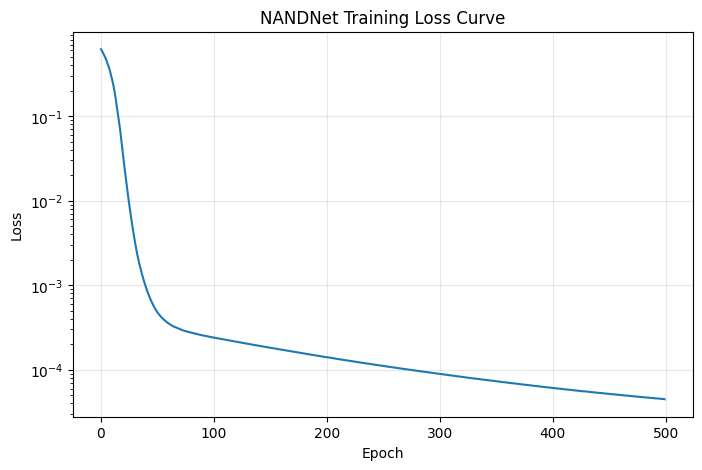

In [21]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)
num_epochs = 500
losses = []

model.train()
for epoch in range(num_epochs):
    epoch_loss = 0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    losses.append(epoch_loss / len(dataloader))
    
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {losses[-1]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.yscale('log')
plt.title("NANDNet Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.show()

In [22]:
model.eval()
with torch.no_grad():
    X_nand = X_nand.to(device)
    y_nand = y_nand.to(device)
    
    logits = model(X_nand)
    probs = torch.sigmoid(logits)
    preds = (probs >= 0.5).float()
    
    accuracy = (preds == y_nand).float().mean()
    print(f"\nAccuracy: {accuracy.item()*100:.2f}%\n")
    
    inputs_np = X_nand.cpu().numpy()
    labels_np = y_nand.cpu().numpy()
    probs_np = probs.cpu().numpy()
    preds_np = preds.cpu().numpy()
    
    print(f"{'Input':<12} | {'True':<6} | {'Prob':<8} | {'Pred':<6} | {'Status'}")
    print("-" * 55)
    for i in range(len(inputs_np)):
        status = "Dung" if preds_np[i] == labels_np[i] else "Sai"
        print(f"{str(inputs_np[i]):<12} | {labels_np[i][0]:<6.0f} | {probs_np[i][0]:<8.4f} | {preds_np[i][0]:<6.0f} | {status}")

model.train()


Accuracy: 100.00%

Input        | True   | Prob     | Pred   | Status
-------------------------------------------------------
[0. 0.]      | 1      | 1.0000   | 1      | Dung
[0. 1.]      | 1      | 1.0000   | 1      | Dung
[1. 0.]      | 1      | 0.9999   | 1      | Dung
[1. 1.]      | 0      | 0.0001   | 0      | Dung


NANDNet(
  (fc1): Linear(in_features=2, out_features=4, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=4, out_features=1, bias=True)
)

Sử dụng sai hàm mất mát: Code mẫu sử dụng nn.MSELoss(). Đối với bài toán phân loại đa lớp (3 lớp), hàm mất mát tiêu chuẩn phải là nn.CrossEntropyLoss(). MSE thường chỉ dùng cho bài toán hồi quy.

Sai kiểu dữ liệu của nhãn (Target): nn.CrossEntropyLoss trong PyTorch yêu cầu nhãn phải là kiểu số nguyên (torch.long) đại diện cho chỉ số lớp. Việc chuyển sang y.float() là sai và sẽ gây lỗi khi đưa vào hàm CrossEntropy.

Sai hàm kích hoạt khi tính Accuracy: Code mẫu dùng torch.sigmoid() cho bài toán 3 lớp. Đối với phân loại đa lớp, hàm kích hoạt phù hợp để tính xác suất là torch.softmax(). Tuy nhiên, để lấy lớp có dự đoán cao nhất, ta có thể dùng trực tiếp argmax() trên logits mà không cần qua sigmoid hay softmax.

Lỗi thiết bị (Kaggle GPU): Code không có cấu hình device. Khi chạy trên Kaggle GPU, nếu không đẩy mô hình và dữ liệu lên GPU, tốc độ sẽ chậm hoặc bị lỗi nếu các thành phần nằm trên các thiết bị khác nhau.

Lỗi logic hình học của Loss: nn.MSELoss yêu cầu đầu ra và nhãn có cùng shape. Ở đây outputs có shape (60, 3) còn y có shape (60,), điều này sẽ gây lỗi mismatch hoặc kết quả tính toán sai lệch hoàn toàn.

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)

X = torch.randn(60, 4).to(device)
y = torch.randint(0, 3, (60,)).to(device)

class MLP3Class(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(4, 8)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(8, 3)
    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

model = MLP3Class().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

for epoch in range(100):
    outputs = model(X)
    loss = criterion(outputs, y)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}: Loss = {loss.item():.4f}")

model.eval()
with torch.no_grad():
    outputs = model(X)
    pred_cls = outputs.argmax(dim=1)
    acc = (pred_cls == y).float().mean()
    print(f"Accuracy: {acc.item()*100:.2f}%")

Epoch 20: Loss = 1.0328
Epoch 40: Loss = 1.0057
Epoch 60: Loss = 0.9871
Epoch 80: Loss = 0.9725
Epoch 100: Loss = 0.9593
Accuracy: 53.33%
